# Empirical Validation of Queueing Assumptions in a Microservice System

The main goal of the experiment is to assess whether
the conditions required by standard analytical queueing models (M/M/1, M/M/c) actually hold in a real environment.

The deployed topology consists of four services:
- **s0**: Entry point, calls s1 & sdb1 in parallel
- **s1**: Service, calls s2 & sdb1 in parallel
- **s2**: Service, calls sdb1
- **sdb1**: Database node, called by all upstream services

Analysis will target 4 core assumptions of a Markovian open queueing network:
1. **Poisson Arrival Process**
2. **Exponential Service Times**
3. **Single Server per Service**
4. **Infinite Buffer**

Beyond these tests, notebook includes:
- **Little's Law**
- **Visit Ratio Validation**
- **Bottleneck Identification**
- **E2E Black Box Analysis** 

## Imports

In [23]:
import json
import numpy as np
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

%matplotlib inline
import matplotlib.pyplot as plt

## Constants

In [24]:
RUNNER_RESULT_FILE = "../../SimulationWorkspace/Result/runner_medium_results.txt"
WORKLOAD_FILE = "../../SimulationWorkspace/medium_load.json"

JAEGER_FILE = "../../spe-project/data/jaeger/spans_medium.json"
PROMETHEUS_FILE = "../../spe-project/data/prometheus/prometheus_medium.json"

SERVICES = ["s0.default", "s1.default", "s2.default", "sdb1.default"]

KS_CAP = 500
P_VALUE = 0.05
WORKERS_PER_SERVICE = 4

# ensure reproducibility
np.random.seed(42)

## Helper Methods

In [25]:
def load_spans():
    with open(JAEGER_FILE) as f:
        return json.load(f)


def load_prometheus():
    with open(PROMETHEUS_FILE) as f:
        return json.load(f)


def load_workload():
    with open(WORKLOAD_FILE) as f:
        return json.load(f)


def load_runner_results():
    rows = []
    with open(RUNNER_RESULT_FILE) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("timestamp"):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            rows.append(parts)
    return rows


# Use prometheus data to calculate the mean following: mean = total_sum / total_count
def prometheus_mean(data, metric_count, metric_sum, service):

    # Get count
    count_results = data.get("increase", {}).get(metric_count, {}).get(service, [])

    # Get sum
    sum_results = data.get("increase", {}).get(metric_sum, {}).get(service, [])

    if not count_results or not sum_results:
        return None

    try:
        # Covert to float for division
        total_count = float(count_results[0]["value"][1])
        total_sum = float(sum_results[0]["value"][1])
    except (KeyError, IndexError, ValueError, TypeError):
        return None

    # Avoid division by zero
    if total_count <= 0:
        return None

    return total_sum / total_count


# Some of the analyses we conduct need a flat array for computing CVs, goodness of fit tests etc.,
# so here we convert bucket counters into an approximate list of individual samples:
# - Remove +Inf bucket as it is not a finite interval
# - Convert cumulative bucket counts into per-bucket counts
# - Convert scrape-to-scrape counter growth into new observations
# - Represent each observation by the midpoint of its bucket
#
# The consideration of course is that this is an approximation that is
# good enough for distributional analysis
def reconstruct_samples_from_histogram_buckets(bucket_results):

    finite_buckets = []

    for bucket in bucket_results:
        # Each bucket has a "le" label that indicates its upper latency bound
        le = bucket["metric"]["le"]

        # Do not consider the +Inf bucket
        if le == "+Inf":
            continue

        # Keep only buckets with le that is finite
        finite_buckets.append((float(le), bucket["values"]))

    finite_buckets.sort(key=lambda x: x[0])
    reconstructed_samples = []
    previous_le = 0.0
    previous_cumulative_series = None

    for upper_le, scrape_values in finite_buckets:
        # For one bucket, extract cumulative counter
        cumulative_series = np.array([float(v[1]) for v in scrape_values])

        if previous_cumulative_series is None:
            # For the very first bucket, there is no smaller bucket to subtract, so
            # so its cumulative series already represents the count for that bucket
            bucket_series = cumulative_series
        else:
            # To isolate requests belonging only to current bucket,
            # we subtract previous bucket's cumulative series
            bucket_series = cumulative_series - previous_cumulative_series

        # bucket_series still tells us the cumulative number of requests that
        # have ever fallen into this bucket up to each scrape time
        # So, to recover how many new requests appeared between consecutive
        # scrapes, we difference the series over time.
        new_counts = np.diff(bucket_series, prepend=0.0)

        # Since we only know that a request fell somewhere inside this bucket,
        # we approximate its latency by the bucket midpoint
        midpoint = (previous_le + upper_le) / 2.0

        for count in new_counts:
            count_int = int(round(count))
            if count_int > 0:
                reconstructed_samples.extend([midpoint] * count_int)

        previous_le = upper_le
        previous_cumulative_series = cumulative_series

    return np.array(reconstructed_samples)


all_spans = load_spans()
prom_data = load_prometheus()
runner_rows = load_runner_results()
workload = load_workload()

## Assumption 1: Poisson Arrival Process

As we know a Poisson arrival process has one defining property, that is the time between consecutive
arrivals (inter-arrival time) must be exponentially distributed &
independent of one another. So, each arrival is memoryless & unaffected by previous ones.

To verify this we analyze the following:
1. **Traffic Generator**: Verify the correctness of the ground truth. A safe check, which should pass by design.
2. **Actual Traffic Send by Runner**: Did the Runner manage to send the planned Poisson process intact?
3. **Arrivals at actual services**: Checks whether internal arrival streams
   also look Poisson. Under the assumptions of an ideal Markovian open
   queueing network, internal flows are expected to remain Poisson.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ASSUMPTION 1: Poisson Arrivals at s0 (Traffic Generator)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean IAT            : 0.2035 s
  Std IAT             : 0.2057 s
  CV                  : 1.0104  (Poisson expects 1.0)
  KS statistic        : 0.0282
  KS p-value          : 0.8103
  Verdict             : PASS : cannot reject exponential


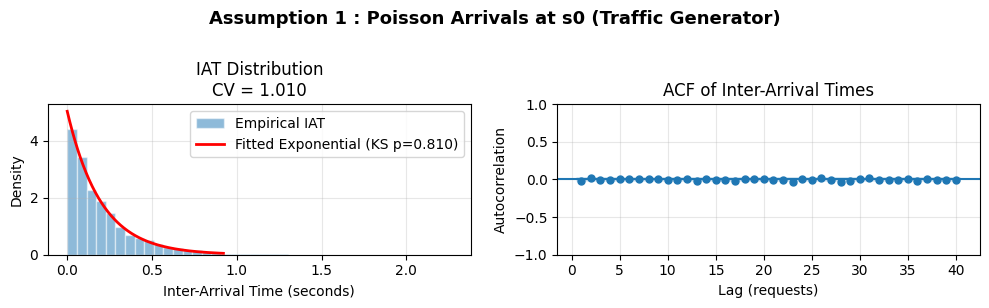


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ASSUMPTION 1 : Poisson Arrivals at s0 (Realized)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean IAT            : 0.2102 s
  Std IAT             : 0.2056 s
  CV                  : 0.9780  (Poisson expects 1.0)
  KS statistic        : 0.0603
  KS p-value          : 0.0505
  Exponential fit check: PASS : cannot reject exponential


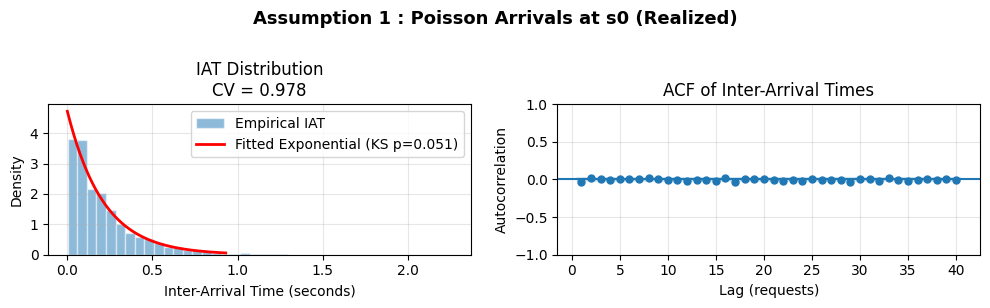


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ASSUMPTION 1 : Poisson Arrivals (All Services)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  s0.default:
    Spans               : 5000
    Mean IAT            : 0.2032 s
    CV                  : 1.0529  (Poisson expects 1.0)
    KS statistic        : 0.1508
    KS p-value          : 0.0000
    Verdict             : FAIL : reject exponential

  s1.default:
    Spans               : 5000
    Mean IAT            : 0.2067 s
    CV                  : 0.5181  (Poisson expects 1.0)
    KS statistic        : 0.2443
    KS p-value          : 0.0000
    Verdict             : FAIL : reject exponential

  s2.default:
    Spans               : 5000
    Mean IAT            : 0.2067 s
    CV                  : 0.5210  (Poisson expects 1.0)
    KS statistic        : 0.2309
    KS p-value          : 0.0000
    Verdict             : FAIL : reject exponential

  sdb1.default:
    Spans               : 

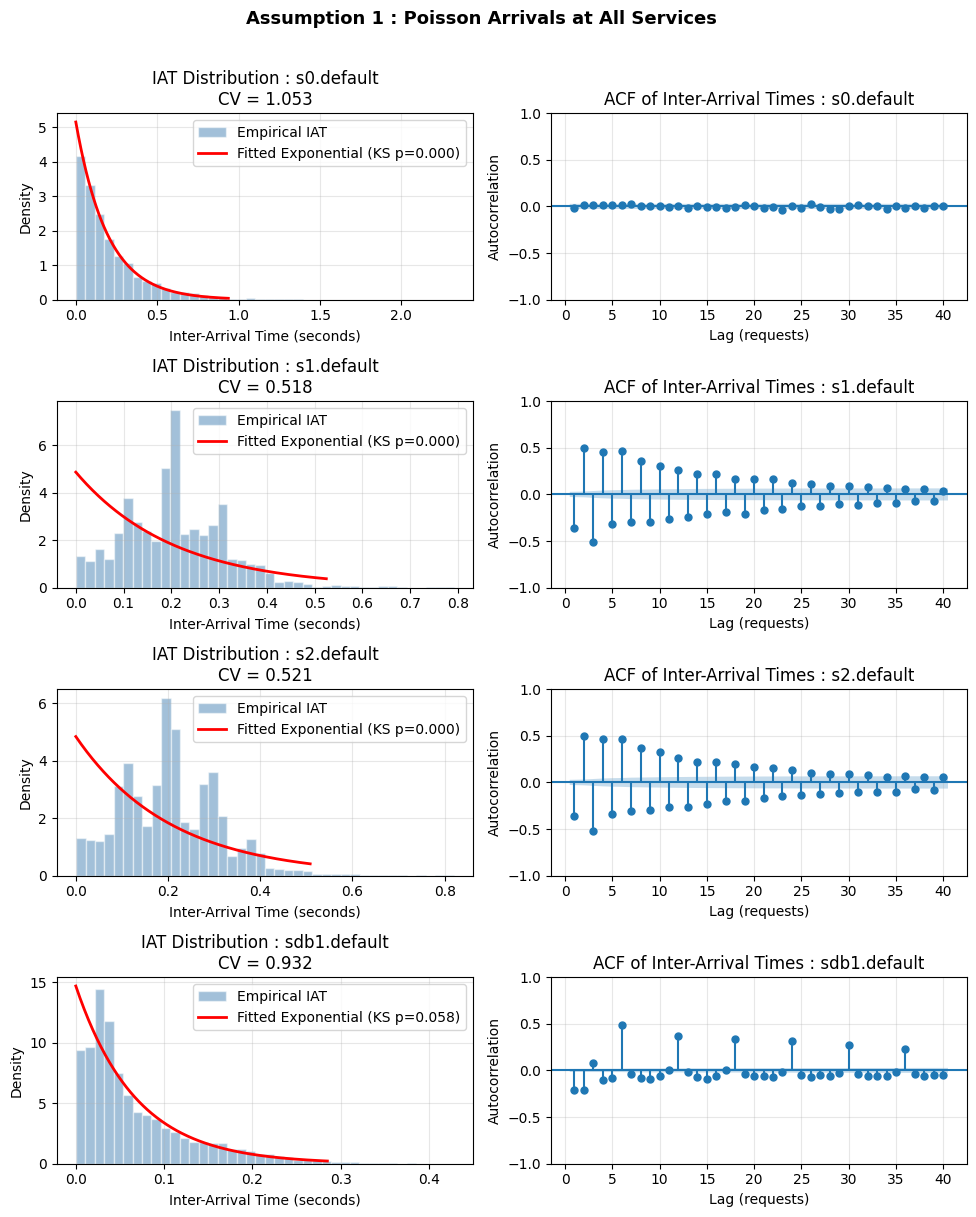

In [26]:
# Here we are not yet measuring what the system actually received.
# Simple validation on the input schedule itself, using the timestamps
# written in workload.json before execution effects such as OS jitter,
# thread scheduling, or dispatch delay can distort it.
def analyse_poisson_generator(workload):

    print("\n" + "━" * 70)
    print("  ASSUMPTION 1: Poisson Arrivals at s0 (Traffic Generator)")
    print("━" * 70)

    # Sort timestamps so that consecutive differences represent the
    # intended time gap between one generated arrival & next
    arrival_times_ms = [entry["time"] for entry in workload]
    arrival_times_ms = sorted(arrival_times_ms)

    # Compute gaps between consecutive arrivals, convert ms -> seconds
    inter_arrival_times_s = np.diff(arrival_times_ms) / 1000.0

    # Remove zero-length gaps if they exist.
    inter_arrival_times_s = inter_arrival_times_s[inter_arrival_times_s > 0]

    # Calculate some general descriptive statistics give a quick check before the
    # formal goodness-of-fit test
    mean_iat = np.mean(inter_arrival_times_s)
    std_iat = np.std(inter_arrival_times_s, ddof=1)
    coefficient_of_variation = std_iat / mean_iat

    # Fit exponential distribution to the observed inter-arrival
    # times & test whether sample is compatible with that fit
    #
    # KS tests are sensitive to large samples, so we cap
    # sample size to just 500
    ks_data = inter_arrival_times_s
    if len(ks_data) > KS_CAP:
        ks_data = np.random.choice(inter_arrival_times_s, size=KS_CAP, replace=False)
    exp_loc, exp_scale = stats.expon.fit(ks_data, floc=0)
    ks_statistic, ks_pvalue = stats.kstest(ks_data, "expon", args=(exp_loc, exp_scale))

    verdict = (
        "FAIL : reject exponential"
        if ks_pvalue < P_VALUE
        else "PASS : cannot reject exponential"
    )

    print(f"  Mean IAT            : {mean_iat:.4f} s")
    print(f"  Std IAT             : {std_iat:.4f} s")
    print(
        f"  CV                  : {coefficient_of_variation:.4f}  (Poisson expects 1.0)"
    )
    print(f"  KS statistic        : {ks_statistic:.4f}")
    print(f"  KS p-value          : {ks_pvalue:.4f}")
    print(f"  Verdict             : {verdict}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(
        "Assumption 1 : Poisson Arrivals at s0 (Traffic Generator)",
        fontsize=13,
        fontweight="bold",
        y=1.01,
    )

    axes[0].hist(
        inter_arrival_times_s,
        bins=40,
        density=True,
        alpha=0.5,
        edgecolor="white",
        label="Empirical IAT",
    )
    x_range = np.linspace(0, np.percentile(inter_arrival_times_s, 99), 300)
    axes[0].plot(
        x_range,
        stats.expon.pdf(x_range, exp_loc, exp_scale),
        "r-",
        lw=2,
        label=f"Fitted Exponential (KS p={ks_pvalue:.3f})",
    )
    axes[0].set_title(f"IAT Distribution\nCV = {coefficient_of_variation:.3f}")
    axes[0].set_xlabel("Inter-Arrival Time (seconds)")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ACF is used as an independence check
    max_lags = min(40, len(inter_arrival_times_s) // 3)
    plot_acf(inter_arrival_times_s, ax=axes[1], lags=max_lags, alpha=0.05, zero=False)
    axes[1].set_title("ACF of Inter-Arrival Times")
    axes[1].set_xlabel("Lag (requests)")
    axes[1].set_ylabel("Autocorrelation")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Here we check if the scheduled process was actually realized by the
# runner itself
def analyse_poisson_realized(runner_rows):
    print("\n" + "━" * 70)
    print("  ASSUMPTION 1 : Poisson Arrivals at s0 (Realized)")
    print("━" * 70)

    # Sort timestamps so that consecutive differences represent the
    # intended time gap between one generated arrival & next
    arrival_times_ms = [int(row[0]) for row in runner_rows]
    arrival_times_ms = sorted(arrival_times_ms)

    # Compute gaps between consecutive arrivals, convert ms -> seconds
    inter_arrival_times_s = np.diff(arrival_times_ms) / 1000.0

    # Remove zero-length gaps if they exist.
    inter_arrival_times_s = inter_arrival_times_s[inter_arrival_times_s > 0]

    # Calculate some general descriptive statistics give a quick check before the
    # formal goodness-of-fit test
    mean_iat = np.mean(inter_arrival_times_s)
    std_iat = np.std(inter_arrival_times_s, ddof=1)
    coefficient_of_variation = std_iat / mean_iat

    # Fit exponential distribution to the observed inter-arrival
    # times & test whether sample is compatible with that fit
    #
    # KS tests are sensitive to large samples, so we cap
    # sample size to just 500
    ks_data = inter_arrival_times_s
    if len(ks_data) > KS_CAP:
        ks_data = np.random.choice(inter_arrival_times_s, size=KS_CAP, replace=False)
    exp_loc, exp_scale = stats.expon.fit(ks_data, floc=0)
    ks_statistic, ks_pvalue = stats.kstest(ks_data, "expon", args=(exp_loc, exp_scale))

    verdict = (
        "FAIL : reject exponential"
        if ks_pvalue < P_VALUE
        else "PASS : cannot reject exponential"
    )

    print(f"  Mean IAT            : {mean_iat:.4f} s")
    print(f"  Std IAT             : {std_iat:.4f} s")
    print(
        f"  CV                  : {coefficient_of_variation:.4f}  (Poisson expects 1.0)"
    )
    print(f"  KS statistic        : {ks_statistic:.4f}")
    print(f"  KS p-value          : {ks_pvalue:.4f}")
    print(f"  Exponential fit check: {verdict}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(
        "Assumption 1 : Poisson Arrivals at s0 (Realized)",
        fontsize=13,
        fontweight="bold",
        y=1.01,
    )

    axes[0].hist(
        inter_arrival_times_s,
        bins=40,
        density=True,
        alpha=0.5,
        edgecolor="white",
        label="Empirical IAT",
    )
    x_range = np.linspace(0, np.percentile(inter_arrival_times_s, 99), 300)
    axes[0].plot(
        x_range,
        stats.expon.pdf(x_range, exp_loc, exp_scale),
        "r-",
        lw=2,
        label=f"Fitted Exponential (KS p={ks_pvalue:.3f})",
    )
    axes[0].set_title(f"IAT Distribution\nCV = {coefficient_of_variation:.3f}")
    axes[0].set_xlabel("Inter-Arrival Time (seconds)")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ACF is used as an independence check
    max_lags = min(40, len(inter_arrival_times_s) // 3)
    plot_acf(inter_arrival_times_s, ax=axes[1], lags=max_lags, alpha=0.05, zero=False)
    axes[1].set_title("ACF of Inter-Arrival Times")
    axes[1].set_xlabel("Lag (requests)")
    axes[1].set_ylabel("Autocorrelation")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Here check whether each service actually sees a Poisson arrival stream
# internally
def analyse_arrivals(all_spans):
    print("\n" + "━" * 70)
    print("  ASSUMPTION 1 : Poisson Arrivals (All Services)")
    print("━" * 70)

    number_of_services = len(SERVICES)
    fig, axes = plt.subplots(
        number_of_services, 2, figsize=(10, 3 * number_of_services)
    )
    fig.suptitle(
        "Assumption 1 : Poisson Arrivals at All Services",
        fontsize=13,
        fontweight="bold",
        y=1.01,
    )

    for service_index, service in enumerate(SERVICES):
        spans = all_spans.get(service, [])

        # Span's start time is the moment service began handling a request,
        # so sorting start times lets us reconstruct the arrival stream
        # observed at that service
        start_times_us = np.array(sorted(span["start_us"] for span in spans))

        # Consecutive start-time differences are the service-level
        # inter-arrival times
        inter_arrival_times_s = np.diff(start_times_us) / 1e6

        # Remove zero-length gaps if they exist.
        inter_arrival_times_s = inter_arrival_times_s[inter_arrival_times_s > 0]

        # Calculate some general descriptive statistics give a quick check before the
        # formal goodness-of-fit test
        mean_iat = np.mean(inter_arrival_times_s)
        std_iat = np.std(inter_arrival_times_s, ddof=1)
        coefficient_of_variation = std_iat / mean_iat

        # Fit exponential & run KS test
        ks_data = inter_arrival_times_s
        if len(ks_data) > KS_CAP:
            ks_data = np.random.choice(
                inter_arrival_times_s, size=KS_CAP, replace=False
            )
        exp_loc, exp_scale = stats.expon.fit(ks_data, floc=0)
        ks_statistic, ks_pvalue = stats.kstest(
            ks_data, "expon", args=(exp_loc, exp_scale)
        )

        verdict = (
            "FAIL : reject exponential"
            if ks_pvalue < P_VALUE
            else "PASS : cannot reject exponential"
        )

        print(f"\n  {service}:")
        print(f"    Spans               : {len(spans)}")
        print(f"    Mean IAT            : {mean_iat:.4f} s")
        print(
            f"    CV                  : {coefficient_of_variation:.4f}  (Poisson expects 1.0)"
        )
        print(f"    KS statistic        : {ks_statistic:.4f}")
        print(f"    KS p-value          : {ks_pvalue:.4f}")
        print(f"    Verdict             : {verdict}")

        axes[service_index, 0].hist(
            inter_arrival_times_s,
            bins=40,
            density=True,
            alpha=0.5,
            color="steelblue",
            edgecolor="white",
            label="Empirical IAT",
        )
        x_range = np.linspace(0, np.percentile(inter_arrival_times_s, 99), 300)
        axes[service_index, 0].plot(
            x_range,
            stats.expon.pdf(x_range, exp_loc, exp_scale),
            "r-",
            lw=2,
            label=f"Fitted Exponential (KS p={ks_pvalue:.3f})",
        )
        axes[service_index, 0].set_title(
            f"IAT Distribution : {service}\nCV = {coefficient_of_variation:.3f}"
        )
        axes[service_index, 0].set_xlabel("Inter-Arrival Time (seconds)")
        axes[service_index, 0].set_ylabel("Density")
        axes[service_index, 0].legend()
        axes[service_index, 0].grid(True, alpha=0.3)

        # ACF validation
        max_lags = min(40, len(inter_arrival_times_s) // 3)
        plot_acf(
            inter_arrival_times_s,
            ax=axes[service_index, 1],
            lags=max_lags,
            alpha=0.05,
            zero=False,
        )
        axes[service_index, 1].set_title(f"ACF of Inter-Arrival Times : {service}")
        axes[service_index, 1].set_xlabel("Lag (requests)")
        axes[service_index, 1].set_ylabel("Autocorrelation")
        axes[service_index, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


analyse_poisson_generator(workload)
analyse_poisson_realized(runner_rows)
analyse_arrivals(all_spans)

## Assumption 2 — Exponential Service Times

For the analytical models to be valid, as we have said the service times at each
node must follow an exponential distribution. So the service process must be memoryless, the remaining service time of a job is independent of how long it has already been served. 

To verify this we analyze the following:
1. **Internal Service Time Distribution**: µBench service cells export a Prometheus histogram of their internal processing latency, the actual time spent executing some local work, excluding downstream calls.
2. **Sojourn Time Distribution**: Here we consider both the service's own internal computation & any time spent waiting for downstream services to reply. This corresponds to a Jaeger span, which is the sojourn time (W) of a node.
3. **Service Time Decomposition**: Provides context for interpreting previous results. For each service we decompose mean sojourn time as: $$W = W_{\text{internal}} + W_{\text{external}}$$


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ASSUMPTION 2: Exponential Internal Service Times
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ────────────────────────────────────────────────────────────
  Service : s0
  ────────────────────────────────────────────────────────────
    Mean internal latency : 0.892 ms
    Service Rate (μ)      : 1120.6326 req/s
    CV                    : 3.1436   (exponential expects 1.0)
    KS statistic          : 0.3807
    KS p-value            : 0.0000
    Verdict               : FAIL — reject exponential

  ────────────────────────────────────────────────────────────
  Service : s1
  ────────────────────────────────────────────────────────────
    Mean internal latency : 408.364 ms
    Service Rate (μ)      : 2.4488 req/s
    CV                    : 0.4347   (exponential expects 1.0)
    KS statistic          : 0.6207
    KS p-value            : 0.0000
    Verdict               : FAIL — reject

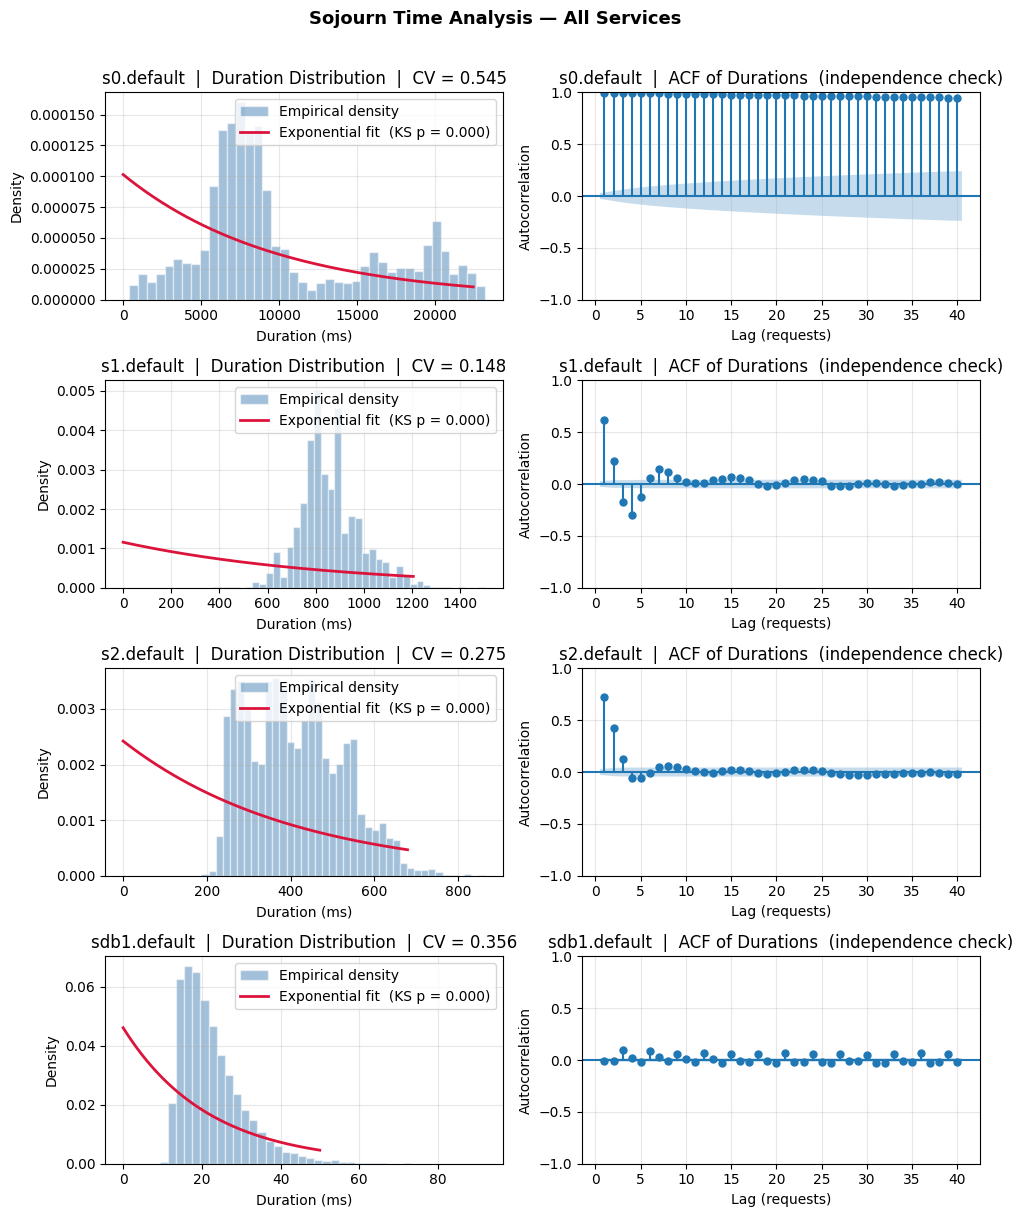


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ASSUMPTION 2: Service Time Decomposition
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Service : s0
    W total     :  823.134 ms
    W internal  :    0.892 ms  (0.1%)
    W external  :  822.058 ms  (99.9%)

  Service : s1
    W total     :  812.706 ms
    W internal  :  408.364 ms  (50.2%)
    W external  :  403.829 ms  (49.7%)

  Service : s2
    W total     :  384.899 ms
    W internal  :  354.206 ms  (92.0%)
    W external  :   30.176 ms  (7.8%)

  Service : sdb1
    W total     :   19.556 ms
    W internal  :   19.166 ms  (98.0%)
    W external  :    0.079 ms  (0.4%)


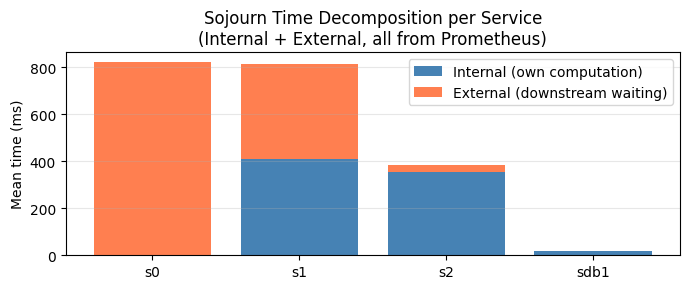

In [27]:
# We test tests the exponential-service assumption, so time spent doing
# own work, excluding time spent waiting for downstream services,
# follows an exponential distribution
#
# Jaeger span duration is not suitable for this purpose as it include downstream wait,
# so for services, we reconstruct approximate internal latency samples from Prometheus
# histogram buckets
def analyse_internal_service_times(prom_data):
    print("\n" + "━" * 70)
    print("  ASSUMPTION 2: Exponential Internal Service Times")
    print("━" * 70)

    prometheus_service_names = ["s0", "s1", "s2", "sdb1"]

    for service in prometheus_service_names:
        print(f"\n  {'─' * 60}")
        print(f"  Service : {service}")
        print(f"  {'─' * 60}")

        mean_internal_ms = prometheus_mean(
            prom_data,
            "mub_internal_processing_latency_milliseconds_count",
            "mub_internal_processing_latency_milliseconds_sum",
            service,
        )

        print(f"    Mean internal latency : {mean_internal_ms:.3f} ms")

        # Get raw histogram bucket time series for service's
        # internal processing metric
        bucket_results = (
            prom_data.get("raw_bucket_series", {})
            .get("mub_internal_processing_latency_milliseconds_bucket_bucket", {})
            .get(service, [])
        )

        # Convert cumulative histogram counters into an
        # approximate flat list of per request internal latencies
        samples_array = reconstruct_samples_from_histogram_buckets(bucket_results)

        # General statistical description
        sample_std = np.std(samples_array, ddof=1)
        cv = sample_std / mean_internal_ms

        # KS test
        ks_data = samples_array
        if len(ks_data) > KS_CAP:
            ks_data = np.random.choice(samples_array, size=KS_CAP, replace=False)
        _loc, exp_scale = stats.expon.fit(ks_data, floc=0)
        ks_statistic, ks_pvalue = stats.kstest(ks_data, "expon", args=(0, exp_scale))

        verdict = (
            "FAIL — reject exponential"
            if ks_pvalue < P_VALUE
            else "PASS — cannot reject exponential"
        )

        print(f"    Service Rate (μ)      : {(1000.0 / mean_internal_ms):.4f} req/s")
        print(f"    CV                    : {cv:.4f}   (exponential expects 1.0)")
        print(f"    KS statistic          : {ks_statistic:.4f}")
        print(f"    KS p-value            : {ks_pvalue:.4f}")
        print(f"    Verdict               : {verdict}")


# The quantity tested here is the full time a request spends inside the service span,
# which includes both:
# 1. Service's own internal work
# 2. Any waiting caused by downstream calls
#
# So essentially here we consider the sojourn-time of services
def analyse_sojourn_times(all_spans):
    print("\n" + "━" * 70)
    print("  ASSUMPTION 2: Sojourn Time Per Service")
    print("━" * 70)

    fig, axes_grid = plt.subplots(len(SERVICES), 2, figsize=(10, 3 * len(SERVICES)))
    fig.suptitle(
        "Sojourn Time Analysis — All Services", fontsize=13, fontweight="bold", y=1.01
    )

    for service_index, service in enumerate(SERVICES):
        ax_hist = axes_grid[service_index, 0]
        ax_acf = axes_grid[service_index, 1]

        # Pull span durations obtained from Jaeger
        spans = all_spans.get(service, [])

        # Convert Jaeger durations into milliseconds
        durations_ms = np.array([span["duration_us"] for span in spans]) / 1000.0

        # General descriptive statistics
        mean_duration = np.mean(durations_ms)
        std_duration = np.std(durations_ms, ddof=1)
        cv = std_duration / mean_duration
        percentile_95 = np.percentile(durations_ms, 95)
        max_duration = np.max(durations_ms)

        # KS test
        ks_data = durations_ms
        if len(ks_data) > KS_CAP:
            ks_data = np.random.choice(durations_ms, size=KS_CAP, replace=False)
        _loc, exp_scale = stats.expon.fit(ks_data, floc=0)
        ks_statistic, ks_pvalue = stats.kstest(ks_data, "expon", args=(0, exp_scale))

        verdict = (
            "FAIL — reject exponential"
            if ks_pvalue < P_VALUE
            else "PASS — cannot reject exponential"
        )

        print(f"\n  {'─' * 60}")
        print(f"  Service : {service}")
        print(f"  {'─' * 60}")
        print(f"    Mean           : {mean_duration:>10.3f} ms")
        print(f"    Std            : {std_duration:>10.3f} ms")
        print(f"    CV             : {cv:>10.4f}   (exponential expects 1.0)")
        print(f"    p95            : {percentile_95:>10.3f} ms")
        print(f"    Max            : {max_duration:>10.3f} ms")
        print(f"    KS statistic   : {ks_statistic:>10.4f}")
        print(f"    KS p-value     : {ks_pvalue:>10.4f}")
        print(f"    Verdict        :  {verdict}")

        ax_hist.hist(
            durations_ms,
            bins=40,
            density=True,
            alpha=0.5,
            color="steelblue",
            edgecolor="white",
            label="Empirical density",
        )
        x_range = np.linspace(0, np.percentile(durations_ms, 99), 300)
        ax_hist.plot(
            x_range,
            stats.expon.pdf(x_range, 0, exp_scale),
            color="crimson",
            linewidth=2,
            label=f"Exponential fit  (KS p = {ks_pvalue:.3f})",
        )
        ax_hist.set_title(f"{service}  |  Duration Distribution  |  CV = {cv:.3f}")
        ax_hist.set_xlabel("Duration (ms)")
        ax_hist.set_ylabel("Density")
        ax_hist.legend()
        ax_hist.grid(True, alpha=0.3)

        max_lags = min(40, len(durations_ms) // 3)
        plot_acf(durations_ms, ax=ax_acf, lags=max_lags, alpha=0.05, zero=False)
        ax_acf.set_title(f"{service}  |  ACF of Durations  (independence check)")
        ax_acf.set_xlabel("Lag (requests)")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Here we decomposes mean request time at each service into:
# 1. Internal time spent doing own computation
# 2. External time spent waiting for downstream calls
#
# Not a formal assumption test, rather with an interpretive role, trying to explain
# why sojourn-time distributions may differ sharply from the internal service time distributions
def analyse_mean_sojourn_time(prom_data):
    print("\n" + "━" * 70)
    print("  ASSUMPTION 2: Service Time Decomposition")
    print("━" * 70)

    prometheus_service_names = ["s0", "s1", "s2", "sdb1"]

    bar_labels = []
    internal_means = []
    external_means = []

    for prometheus_service in prometheus_service_names:
        # Mean internal time, work performed locally by the service.
        mean_internal_ms = prometheus_mean(
            prom_data,
            "mub_internal_processing_latency_milliseconds_count",
            "mub_internal_processing_latency_milliseconds_sum",
            prometheus_service,
        )

        # Mean external time, downstream calls
        mean_external_ms = prometheus_mean(
            prom_data,
            "mub_external_processing_latency_milliseconds_count",
            "mub_external_processing_latency_milliseconds_sum",
            prometheus_service,
        )

        # Mean total request time
        mean_total_ms = prometheus_mean(
            prom_data,
            "mub_request_processing_latency_milliseconds_count",
            "mub_request_processing_latency_milliseconds_sum",
            prometheus_service,
        )

        percent_internal = (mean_internal_ms / mean_total_ms) * 100.0
        percent_external = (mean_external_ms / mean_total_ms) * 100.0

        print(f"\n  Service : {prometheus_service}")
        print(f"    W total     : {mean_total_ms:>8.3f} ms")
        print(
            f"    W internal  : {mean_internal_ms:>8.3f} ms  ({percent_internal:.1f}%)"
        )
        print(
            f"    W external  : {mean_external_ms:>8.3f} ms  ({percent_external:.1f}%)"
        )

        bar_labels.append(prometheus_service)
        internal_means.append(mean_internal_ms)
        external_means.append(mean_external_ms)

    x_positions = np.arange(len(bar_labels))
    fig, ax = plt.subplots(figsize=(7, 3))

    ax.bar(
        x_positions,
        internal_means,
        label="Internal (own computation)",
        color="steelblue",
    )
    ax.bar(
        x_positions,
        external_means,
        bottom=internal_means,
        label="External (downstream waiting)",
        color="coral",
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bar_labels)
    ax.set_ylabel("Mean time (ms)")
    ax.set_title(
        "Sojourn Time Decomposition per Service\n(Internal + External, all from Prometheus)"
    )
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


analyse_internal_service_times(prom_data)
analyse_sojourn_times(all_spans)
analyse_mean_sojourn_time(prom_data)

## Assumption 3 — Single Server per Service

The classical M/M/1 queueing model requires that each service centre operates
with exactly one server, meaning that requests are processed one at a time, with
any excess demand forming a queue.

This is something we can verify directly from `workmodel.json`configuration rather than trace data. Number of servers is a deployment decision, not something that needs to be statistically verified, and it is actually explicitly set via the `workers` parameter in the work model.

So in practice With `c = 4` workers, the appropriate single-node model is **M/M/4**, which is going to have:
- **Lower mean queue length**: Multiple servers
- **Lower mean waiting time**: Request only queues if all `c` servers are
  simultaneously busy
- **Higher saturation threshold**: the system reaches instability at
  `λ > c · μ` rather than `λ > μ`

In [28]:
def analyse_single_server():
    print("\n" + "━" * 70)
    print("   ASSUMPTION 3 : Server Multiplicity")
    print("━" * 70)

    print(f"  Workers per service : {WORKERS_PER_SERVICE}")

    if WORKERS_PER_SERVICE == 1:
        print("  Verdict             : PASS (M/M/1 valid)")
    else:
        print("  Verdict             : FAIL (not single-server)")
        print(f"  Correct model       : M/M/c with c={WORKERS_PER_SERVICE}")


analyse_single_server()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ASSUMPTION 3 : Server Multiplicity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Workers per service : 4
  Verdict             : FAIL (not single-server)
  Correct model       : M/M/c with c=4


## Assumption 4 — Infinite Buffer

In classical models we assume that every queue has infinite capacity, so in
practice this means system must never reject or drop a request due to
resource exhaustion, full buffers, or timeout policies. 

We verify this using the txt result file produced by the Runner, which records HTTP status
code returned for every request. 

Any non-200 response indicates that a request was not successfully served, which is treated as a drop from the queueing model’s perspective.

In [29]:
def analyse_infinite_buffer(runner_rows):
    print("\n" + "━" * 70)
    print("    ASSUMPTION 4 : Infinite Buffer")
    print("━" * 70)

    total_requests = len(runner_rows)
    non_200 = 0

    for row in runner_rows:
        status = row[2]
        if status != "200":
            non_200 += 1

    percentage = (non_200 / total_requests) * 100.0

    print(f"  Total requests      : {total_requests}")
    print(f"  Non-200 responses   : {non_200}")

    if non_200 == 0:
        print("  Verdict             : PASS")
    else:
        print(f"  Verdict             : FAIL ({percentage:.2f}% non-200)")


analyse_infinite_buffer(runner_rows)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ASSUMPTION 4 : Infinite Buffer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total requests      : 5000
  Non-200 responses   : 0
  Verdict             : PASS


## Further Considerations

### Little's Law

Little's Law states that for any stable queueing system:

$$L = \lambda \cdot W$$

where $L$ is the mean number of requests in the system, $\lambda$ is the
arrival rate, and $W$ is the mean sojourn time. 

We cannot directly observe $L$ from our instrumentation.
1. Jaeger gives us $W$ per request
2. Runner gives us $\lambda$. 

Little's Law is therefore the only way to estimate $L$ empirically, and we use it exactly for that purpose.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Little's Law
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Service      W_i (s)     X_i (req/s)     L_i = X_i W_i
  ───────      ───────     ───────────     ─────────────
  s0           10.2501          4.8294           49.5021
  s1            0.8593          4.8364            4.1561
  s2            0.4110          4.8373            1.9880
  sdb1          0.0225         14.5093            0.3270


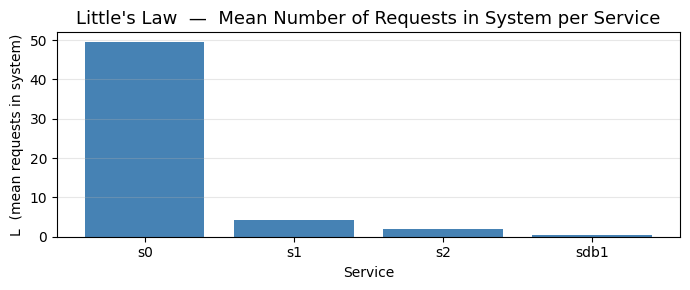

In [30]:
# Here we apply Little's Law separately to each service, with the
# goal to estimate mean number of requests present at each
# service
# - W_i is the mean time spent in a service, taken from Jaeger span durations
# - X_i is the completed throughput at service i, computed from same
#   set of spans
def analyse_littles_law(all_spans):
    print("\n" + "━" * 70)
    print("  Little's Law")
    print("━" * 70)

    services = ["s0", "s1", "s2", "sdb1"]

    print(
        f"\n  {'Service':<8}  {'W_i (s)':>10}  {'X_i (req/s)':>14}  {'L_i = X_i W_i':>16}"
    )
    print(
        f"  {'───────':<8}  {'───────':>10}  {'───────────':>14}  {'─────────────':>16}"
    )

    results = {}

    for service in services:
        jaeger_service = f"{service}.default"

        spans = all_spans.get(jaeger_service, [])

        # Each span gives:
        # Start time, which tells us when service activity began
        # Duration, which tells us how long that visit stayed in the service
        start_times_s = np.array([span["start_us"] for span in spans]) / 1e6
        durations_s = np.array([span["duration_us"] for span in spans]) / 1e6
        end_times_s = start_times_s + durations_s

        # Measured directly from Jaeger span durations
        mean_sojourn_s = np.mean(durations_s)

        # Throughput must be measured over the same service level observation
        # window as the spans used for W_i
        observation_window_s = end_times_s.max() - start_times_s.min()

        # Here we calculate completed throughput at this service
        throughput_i = len(spans) / observation_window_s

        # Little's Law
        mean_requests_in_system = throughput_i * mean_sojourn_s

        results[service] = {
            "mean_sojourn_s": mean_sojourn_s,
            "throughput_i": throughput_i,
            "mean_requests_in_system": mean_requests_in_system,
        }

        print(
            f"  {service:<8}  {mean_sojourn_s:>10.4f}  "
            f"{throughput_i:>14.4f}  {mean_requests_in_system:>16.4f}"
        )

    service_names = list(results.keys())
    L_values = [results[s]["mean_requests_in_system"] for s in service_names]

    fig, ax = plt.subplots(figsize=(7, 3))

    ax.bar(service_names, L_values, color="steelblue")
    ax.set_title(
        "Little's Law  —  Mean Number of Requests in System per Service",
        fontsize=13,
    )
    ax.set_xlabel("Service")
    ax.set_ylabel("L  (mean requests in system)")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


analyse_littles_law(all_spans)

### Visit Ratio Validation

Here we validate that the traffic actually flows through network as topology dictates. The visit
ratio of a service is defined as the expected number of times that service is visited per request entering the system at s0.

From the workmodel topology the theoretical values are:

| Service | Reason | Expected $V_i$ |
|---------|--------|---------------|
| s0 | entry point, visited once per request | 1.0 |
| s1 | called once by s0 | 1.0 |
| s2 | called once by s1 | 1.0 |
| sdb1 | called independently by s0, s1, and s2 | 3.0 |

Empirically, we estimate $V_i$ by counting the number of server-side Jaeger
spans recorded at each service and dividing by the span count at s0:

$$\hat{V}_i = \frac{\text{spans at service } i}{\text{spans at s0}}$$

Estimate only reflects successfully completed requests, thus may differ from theoretical
values in the presence of request loss.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Visit Ratios
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Service           Spans   Measured V   Expected V   Deviation
  ─────────────     ─────   ──────────   ──────────   ─────────
  s0.default         5000        1.000        1.000      +0.00%
  s1.default         5000        1.000        1.000      +0.00%
  s2.default         5000        1.000        1.000      +0.00%
  sdb1.default      15000        3.000        3.000      +0.00%


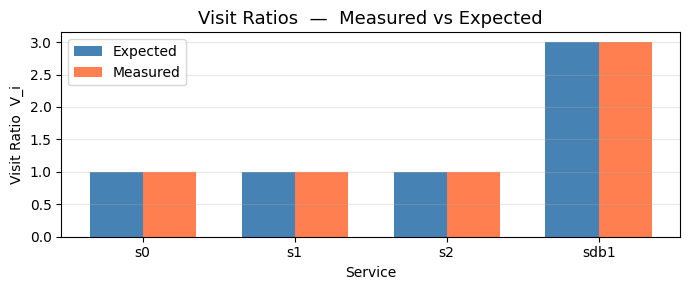

In [31]:
# We check whether the observed routing behavior matches the
# topology implied by the workload design.
# We do this by considering the number of spans at a service, which is treated as the number
# of completed visits to that service. Then we divide by s0 span count to converts that into
# visits per entry request
def analyse_visit_ratios(all_spans):
    print("\n" + "━" * 70)
    print("  Visit Ratios")
    print("━" * 70)

    # These are the theoretical visit ratios implied by the service topology
    expected_visit_ratios = {
        "s0.default": 1.0,
        "s1.default": 1.0,
        "s2.default": 1.0,
        "sdb1.default": 3.0,
    }

    # s0 is the reference point because every external request enters there
    s0_span_count = len(all_spans.get("s0.default", []))

    print(
        f"\n  {'Service':<14}  {'Spans':>7}  {'Measured V':>11}  {'Expected V':>11}  {'Deviation':>10}"
    )
    print(
        f"  {'─────────────':<14}  {'─────':>7}  {'──────────':>11}  {'──────────':>11}  {'─────────':>10}"
    )

    measured_ratios = {}

    for service in SERVICES:
        # Count how many traced visits were recorded for service
        span_count = len(all_spans.get(service, []))

        # Empirical visit ratio
        measured_ratio = span_count / s0_span_count

        # Topology based expected ratio
        expected_ratio = expected_visit_ratios.get(service, None)

        measured_ratios[service] = measured_ratio

        deviation_pct = ((measured_ratio - expected_ratio) / expected_ratio) * 100.0
        print(
            f"  {service:<14}  {span_count:>7}  {measured_ratio:>11.3f}  "
            f"{expected_ratio:>11.3f}  {deviation_pct:>+9.2f}%"
        )

    service_labels = [s.replace(".default", "") for s in SERVICES]
    measured_values = [measured_ratios[s] for s in SERVICES]
    expected_values = [expected_visit_ratios.get(s, 0) for s in SERVICES]

    x_positions = np.arange(len(service_labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(7, 3))

    ax.bar(
        x_positions - bar_width / 2,
        expected_values,
        bar_width,
        label="Expected",
        color="steelblue",
    )
    ax.bar(
        x_positions + bar_width / 2,
        measured_values,
        bar_width,
        label="Measured",
        color="coral",
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(service_labels)
    ax.set_title("Visit Ratios  —  Measured vs Expected", fontsize=13)
    ax.set_xlabel("Service")
    ax.set_ylabel("Visit Ratio  V_i")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


analyse_visit_ratios(all_spans)

### Bottleneck Identification

Here we have a look at how heavily loaded each service is under the
measured arrival rate.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SERVICE DEMANDS & UTILISATION  —  Operational M/M/c Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Global arrival rate λ = 4.926 req/s

  Service      V_i   λ_i (req/s)    S_i (ms)   μ_i (req/s)       U_i
  ───────      ───   ───────────    ────────   ───────────       ───
  s0         1.000         4.926       0.892      1120.633    0.0011
  s1         1.000         4.926     408.364         2.449    0.5029
  s2         1.000         4.926     354.206         2.823    0.4362
  sdb1       3.000        14.777      19.166        52.175    0.0708

  Bottleneck service      : s1
  Theoretical X_max       : 9.795 req/s
  λ / X_max               : 0.503  (not saturated)


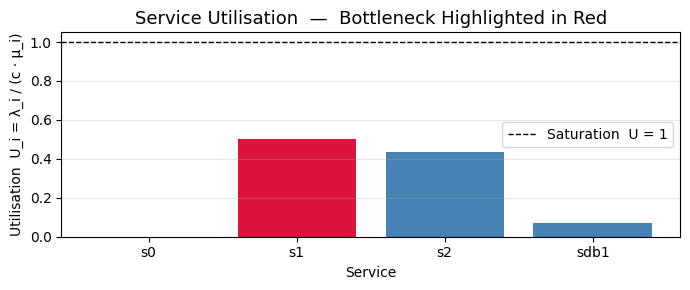

In [32]:
# Here we calculate how heavily loaded each service is under the
# measured workload & then identify the bottleneck
#
# We:
# 1. Measure external arrival rate from the Runner
# 2. Use traced visit ratios to infer how much of that traffic reaches each service
# 3. Use mean internal busy time from Prometheus as the service demand S_i
# 4. Convert that into a per worker service rate μ_i
# 5. Combine arrival rate, service rate, and worker count to estimate utilisation
def analyse_utilization(all_spans, prom_data, runner_rows):
    print("\n" + "━" * 70)
    print("  SERVICE DEMANDS & UTILISATION  —  Operational M/M/c Analysis")
    print("━" * 70)

    # The Runner timestamps describe the offered external request stream
    # We use the total experiment span to convert timestamps into the
    # measured external arrival rate λ
    request_timestamps_ms = sorted([int(row[0]) for row in runner_rows])
    arrival_span_s = (request_timestamps_ms[-1] - request_timestamps_ms[0]) / 1000.0
    global_arrival_rate = (len(request_timestamps_ms) - 1) / arrival_span_s

    print(f"\n  Global arrival rate λ = {global_arrival_rate:.3f} req/s")

    # s0 is the entry service, so its span count is the reference
    # population for visit ratios. We repeat the same process as in
    # the visit ratio analysis
    s0_span_count = len(all_spans.get("s0.default", []))
    services = ["s0", "s1", "s2", "sdb1"]
    jaeger_services = ["s0.default", "s1.default", "s2.default", "sdb1.default"]

    print(
        f"\n  {'Service':<8}  {'V_i':>6}  {'λ_i (req/s)':>12}  {'S_i (ms)':>10}  {'μ_i (req/s)':>12}  {'U_i':>8}"
    )
    print(
        f"  {'───────':<8}  {'───':>6}  {'───────────':>12}  {'────────':>10}  {'───────────':>12}  {'───':>8}"
    )

    results = []

    for prometheus_service, jaeger_service in zip(services, jaeger_services):
        # Visit ratio V_i tells us how many visits service i receives
        visit_ratio = len(all_spans.get(jaeger_service, [])) / s0_span_count

        # Service-level arrival rate:
        # external requests per second × visits per external request.
        arrival_rate_at_service = global_arrival_rate * visit_ratio

        # Since utilisation should be based on the time a worker is actually occupied
        # doing own work, we use internal processing time metrics, coming from Prometheus
        mean_busy_time_ms = prometheus_mean(
            prom_data,
            "mub_internal_processing_latency_milliseconds_count",
            "mub_internal_processing_latency_milliseconds_sum",
            prometheus_service,
        )

        # Obtain service rate μ
        service_rate = 1000.0 / mean_busy_time_ms

        # M/M/c utilisation: ρ_i = λ_i / (c μ_i)
        utilisation = arrival_rate_at_service / (WORKERS_PER_SERVICE * service_rate)

        results.append(
            (
                prometheus_service,
                visit_ratio,
                arrival_rate_at_service,
                mean_busy_time_ms,
                service_rate,
                utilisation,
            )
        )

        print(
            f"  {prometheus_service:<8}  {visit_ratio:>6.3f}  "
            f"{arrival_rate_at_service:>12.3f}  "
            f"{mean_busy_time_ms:>10.3f}  "
            f"{service_rate:>12.3f}  "
            f"{utilisation:>8.4f}"
        )

    # The bottleneck is the service with the highest utilisation
    bottleneck_row = max(results, key=lambda row: row[5])
    bottleneck_name = bottleneck_row[0]

    # Theoretical maximum throughput
    bottleneck_visit_ratio = bottleneck_row[1]
    bottleneck_service_rate = bottleneck_row[4]
    theoretical_x_max = (
        WORKERS_PER_SERVICE * bottleneck_service_rate
    ) / bottleneck_visit_ratio
    saturation_ratio = global_arrival_rate / theoretical_x_max

    print(f"\n  Bottleneck service      : {bottleneck_name}")
    print(f"  Theoretical X_max       : {theoretical_x_max:.3f} req/s")
    print(
        f"  λ / X_max               : {saturation_ratio:.3f}  "
        f"({'near saturation' if saturation_ratio > 0.8 else 'not saturated'})"
    )

    service_names = [row[0] for row in results]
    utilisations = [row[5] for row in results]
    bar_colors = [
        "crimson" if name == bottleneck_name else "steelblue" for name in service_names
    ]

    fig, ax = plt.subplots(figsize=(7, 3))

    ax.bar(service_names, utilisations, color=bar_colors)
    ax.axhline(
        y=1.0, color="black", linestyle="--", linewidth=1, label="Saturation  U = 1"
    )

    ax.set_title("Service Utilisation  —  Bottleneck Highlighted in Red", fontsize=13)
    ax.set_xlabel("Service")
    ax.set_ylabel("Utilisation  U_i = λ_i / (c · μ_i)")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


analyse_utilization(all_spans, prom_data, runner_rows)

### End-to-End Analysis

Here we analyse the system end-to-end, treating the entire microservice as a single black-box entity as seen from an external client.

We:
1. Compute arrival rate λ directly from the experiment duration and request count
2. Derive system service rate μ from the bottleneck service (s1) internal time
3. Compute ρ = λ/μ as a measure of overall system load
4. Compute E2E response time statistics (mean, CV, p95) and test the exponential
   assumption via a KS test
5. Apply Little's Law at the system level using goodput and mean E2E latency

In [33]:
def analyse_e2e_blackbox(runner_rows, all_spans, prom_data):
    print("\n" + "━" * 70)
    print("  END-TO-END BLACK-BOX ANALYSIS")
    print("━" * 70)

    # Parse the runner data 
    requests = []
    for row in runner_rows:
        try:
            requests.append((int(row[0]), float(row[1]), int(row[2])))
        except Exception:
            continue

    # Sort by send time so that consecutive timestamps are in arrival order
    requests.sort(key=lambda x: x[0])
    sent_at_ms = np.array([r[0] for r in requests], dtype=float)
    latency_ms = np.array([r[1] for r in requests], dtype=float)
    status_codes = np.array([r[2] for r in requests], dtype=int)

    # Considered only 200 Ok response code 
    succeeded = (status_codes == 200) & (latency_ms >= 0)
    total_requests = len(sent_at_ms)
    total_succeeded = int(succeeded.sum())
    response_times_ms = latency_ms[succeeded]

    # Calculate lamba, requests per second measured from first to last sent request
    experiment_duration_s = (sent_at_ms[-1] - sent_at_ms[0]) / 1000.0
    lam = (total_requests - 1) / experiment_duration_s

    # Service rate, how many requests per second can the system handle
    # Mu,derive the system service rate from the bottleneck service (S1)
    mean_internal_s1_ms = prometheus_mean(
        prom_data,
        "mub_internal_processing_latency_milliseconds_count",
        "mub_internal_processing_latency_milliseconds_sum",
        "s1",
    )
    mu = 4 * 1000.0 / mean_internal_s1_ms
    rho = lam / mu

    # E2E response time statistics
    mean_rt = np.mean(response_times_ms)
    std_rt = np.std(response_times_ms, ddof=1)
    cv_rt = std_rt / mean_rt
    p95 = np.percentile(response_times_ms, 95)

    # KS test against exponential
    ks_sample = (
        response_times_ms
        if len(response_times_ms) <= KS_CAP
        else np.random.choice(response_times_ms, KS_CAP, replace=False)
    )
    _, exp_scale = stats.expon.fit(ks_sample, floc=0)
    ks_stat, ks_pvalue = stats.kstest(ks_sample, "expon", args=(0, exp_scale))

    # Goodput is the rate at which requests complete successfully
    # Little's Law L = X * W then gives the mean number of requests in the system
    success_finished_ms = sent_at_ms[succeeded] + latency_ms[succeeded]
    completions_ms = np.sort(success_finished_ms)
    completion_span_s = (completions_ms[-1] - completions_ms[0]) / 1000.0
    goodput = (total_succeeded - 1) / completion_span_s
    L = goodput * (mean_rt / 1000.0)

    print(f"\n  λ (arrival rate)          : {lam:.3f} req/s")
    print(f"  μ (system service rate)   : {mu:.3f} req/s")
    print(f"  ρ = λ/μ                   : {rho:.4f}")
    print(
        f"\n  Succeeded                 : {total_succeeded}/{total_requests}  ({100*total_succeeded/total_requests:.1f}%)"
    )
    print(f"  Goodput (X)               : {goodput:.3f} req/s")
    print(f"  Mean E2E latency (W)      : {mean_rt/1000:.4f} s")
    print(f"  CV                        : {cv_rt:.3f}  (exponential expects 1.0)")
    print(f"  p95                       : {p95/1000:.4f} s")
    print(
        f"  KS p-value                : {ks_pvalue:.4f}  ({'PASS' if ks_pvalue >= P_VALUE else 'FAIL'})"
    )
    print(f"  Avg. requests in system L : {L:.2f}")


analyse_e2e_blackbox(runner_rows, all_spans, prom_data)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  END-TO-END BLACK-BOX ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  λ (arrival rate)          : 4.926 req/s
  μ (system service rate)   : 9.795 req/s
  ρ = λ/μ                   : 0.5029

  Succeeded                 : 5000/5000  (100.0%)
  Goodput (X)               : 4.832 req/s
  Mean E2E latency (W)      : 9.7990 s
  CV                        : 0.542  (exponential expects 1.0)
  p95                       : 19.7712 s
  KS p-value                : 0.0000  (FAIL)
  Avg. requests in system L : 47.35
